In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")


# Load the dataset
df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [13]:
# Basic information
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Remove duplicate rows
df = df.drop_duplicates()

# Remove invalid prices
df = df[df["price"] > 0].copy()

# Remove extreme prices above the 99th percentile
price_limit = df["price"].quantile(0.99)
df = df[df["price"] <= price_limit].copy()

print("\nFinal shape after cleaning:", df.shape)
print("Price limit used:", price_limit)

Number of rows: 48895
Number of columns: 16

Missing values:
last_review            10052
reviews_per_month      10052
host_name                 21
name                      16
neighbourhood_group        0
neighbourhood              0
id                         0
host_id                    0
longitude                  0
latitude                   0
dtype: int64

Final shape after cleaning: (48410, 16)
Price limit used: 799.0


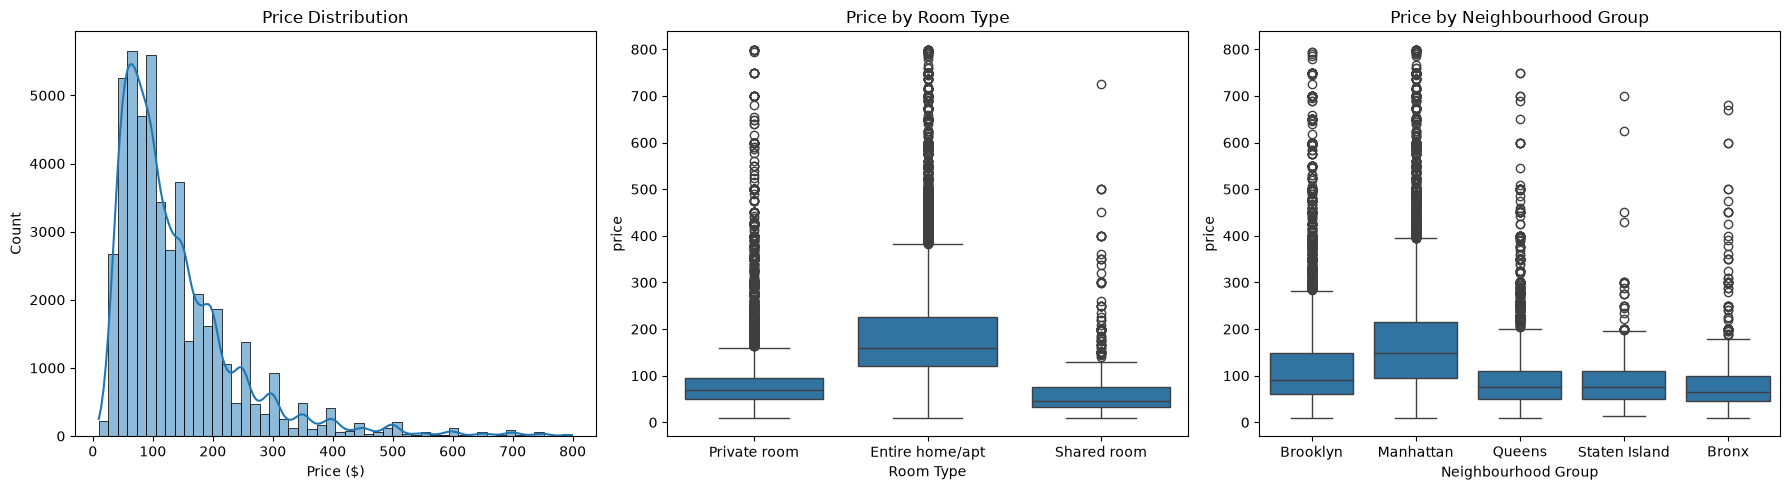

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price distribution
sns.histplot(df["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price ($)")

# Price by room type
sns.boxplot(data=df, x="room_type", y="price", ax=axes[1])
axes[1].set_title("Price by Room Type")
axes[1].set_xlabel("Room Type")

# Price by neighbourhood group
sns.boxplot(
    data=df,
    x="neighbourhood_group",
    y="price",
    ax=axes[2]
)
axes[2].set_title("Price by Neighbourhood Group")
axes[2].set_xlabel("Neighbourhood Group")

plt.tight_layout()
plt.show()

In [15]:
# Median price by room type
df.groupby("room_type")["price"].median().sort_values(ascending=False)

room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: price, dtype: float64

In [16]:
# Remove columns that are not useful for this model
drop_columns = [
    "id",
    "name",
    "host_id",
    "host_name",
    "last_review"
]

df_model = df.drop(columns=drop_columns)

# Create a few useful features
df_model["reviews_per_availability"] = (
    df_model["number_of_reviews"] /
    (df_model["availability_365"] + 1)
)

df_model["minimum_nights_log"] = np.log1p(
    df_model["minimum_nights"]
)

df_model["reviews_log"] = np.log1p(
    df_model["number_of_reviews"]
)

df_model["availability_log"] = np.log1p(
    df_model["availability_365"]
)

print("Features being used:")
print(df_model.drop(columns="price").columns.tolist())

Features being used:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'reviews_per_availability', 'minimum_nights_log', 'reviews_log', 'availability_log']


In [17]:
# Separate input features and target
X = df_model.drop("price", axis=1)
y = df_model["price"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Identify column types
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Numerical preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 38728
Testing samples: 9682


In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10),
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    )
}

results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])
    trained_models[name] = pipeline

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_df.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,Random Forest,44.847215,72.941561,0.511073
1,Ridge Regression,49.465842,78.776250,0.429724
0,Linear Regression,49.525611,78.792007,0.429496


In [20]:
# Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# A small parameter grid
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 15],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters:
{'model__max_depth': 15, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [21]:
# Final tuned model
final_model = grid_search.best_estimator_

# Predictions
train_predictions = final_model.predict(X_train)
test_predictions = final_model.predict(X_test)

# Training metrics
train_rmse = np.sqrt(
    mean_squared_error(y_train, train_predictions)
)
train_r2 = r2_score(y_train, train_predictions)

# Testing metrics
test_mae = mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(
    mean_squared_error(y_test, test_predictions)
)
test_r2 = r2_score(y_test, test_predictions)

print("Final Model Performance")
print("-----------------------")
print(f"Test MAE  : {test_mae:.2f}")
print(f"Test RMSE : {test_rmse:.2f}")
print(f"Test R²   : {test_r2:.4f}")

print("\nOverfitting Check")
print("-----------------")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE : {test_rmse:.2f}")
print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")

Final Model Performance
-----------------------
Test MAE  : 44.25
Test RMSE : 72.36
Test R²   : 0.5189

Overfitting Check
-----------------
Train RMSE: 53.14
Test RMSE : 72.36
Train R²  : 0.7371
Test R²   : 0.5189


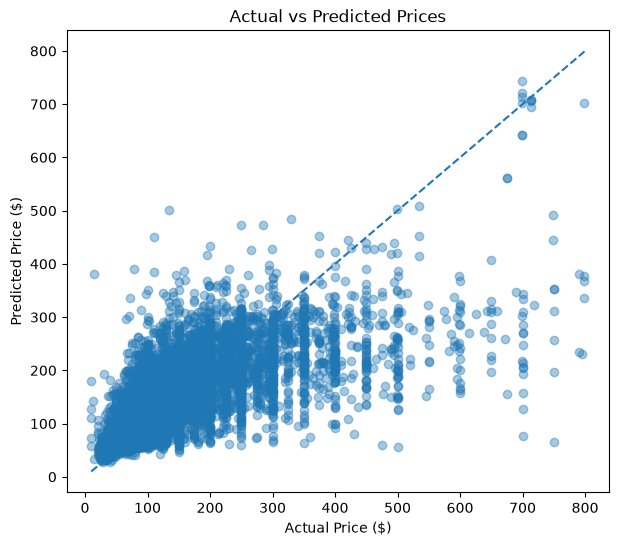

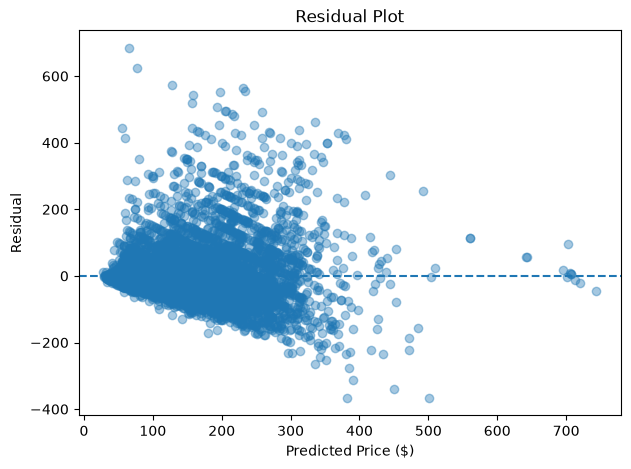

In [22]:
# Actual vs predicted prices
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.4
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()


# Residual plot
residuals = y_test - test_predictions

plt.figure(figsize=(7, 5))

plt.scatter(
    test_predictions,
    residuals,
    alpha=0.4
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

Top 15 important features:


cat__room_type_Entire home/apt         0.348652
num__longitude                         0.156095
num__latitude                          0.116000
num__reviews_per_availability          0.068740
num__calculated_host_listings_count    0.045213
num__reviews_per_month                 0.040720
num__availability_log                  0.033296
num__availability_365                  0.032430
cat__neighbourhood_Midtown             0.027910
num__minimum_nights                    0.026349
num__minimum_nights_log                0.025997
num__reviews_log                       0.010520
num__number_of_reviews                 0.010515
cat__neighbourhood_Tribeca             0.003712
cat__neighbourhood_group_Manhattan     0.003545
dtype: float64

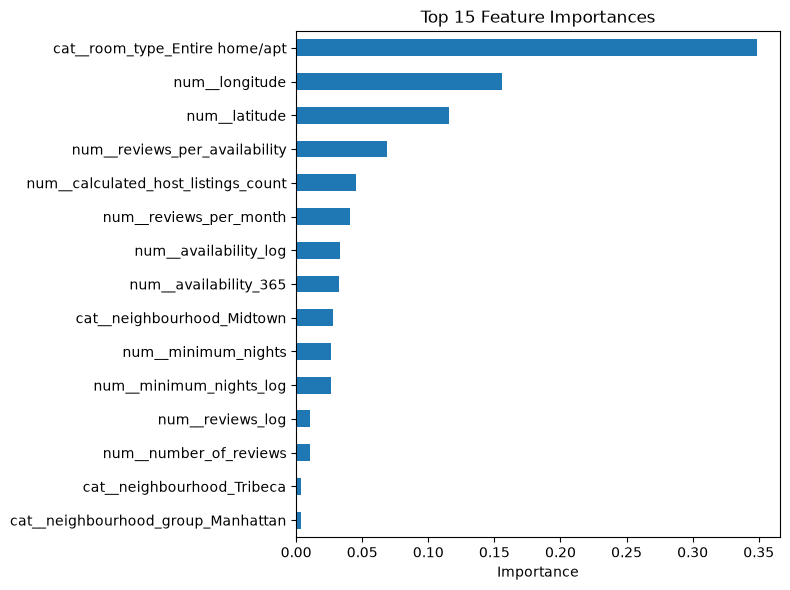

Model saved successfully!


In [24]:
# Get the trained Random Forest
rf_model = final_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Create feature importance table
importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Top 15 important features:")
display(importance.head(15))

# Plot top features
plt.figure(figsize=(8, 6))

importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

# Save the complete pipeline
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the complete pipeline
joblib.dump(
    final_model,
    "../models/airbnb_price_pipeline.pkl"
)

print("Model saved successfully!")

In [25]:
import os

# Create the models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the complete pipeline
joblib.dump(
    final_model,
    "../models/airbnb_price_pipeline.pkl"
)

print("Model saved successfully!")

Model saved successfully!
